In [1]:
import torch
import os
import random
import utils
import data_utils
import json

import cbm
import plots

/home/jovyan/Label-free-CBM/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


In [2]:
# change this to the correct model dir, everything else should be taken care of
load_dir = "saved_models/cub_lf_cbm"
device = "cuda"

with open(os.path.join(load_dir, "args.txt"), "r") as f:
    args = json.load(f)
dataset = args["dataset"]
_, target_preprocess = data_utils.get_target_model(args["backbone"], device)
model = cbm.load_cbm(load_dir, device)

In [3]:
val_d_probe = dataset+"_val"
cls_file = data_utils.LABEL_FILES[dataset]

val_data_t = data_utils.get_data(val_d_probe, preprocess=target_preprocess)
val_pil_data = data_utils.get_data(val_d_probe)

In [4]:
with open(cls_file, "r") as f:
    classes = f.read().split("\n")

with open(os.path.join(load_dir, "concepts.txt"), "r") as f:
    concepts = f.read().split("\n")

## Measure accuracy

In [5]:
accuracy = utils.get_accuracy_cbm(model, val_data_t, device)
print("Accuracy: {:.2f}%".format(accuracy*100))

100%|██████████| 24/24 [03:13<00:00,  8.07s/it]

Accuracy: 74.56%


## Show final layer weights for some classes

You can build a Sankey diagram of weights by copying the incoming weights printed below into https://sankeymatic.com/build/

In [6]:
to_show = random.choices([i for i in range(len(classes))], k=1)

for i in to_show:
    print("Output class:{} - {}".format(i, classes[i]))
    print("Incoming weights:")
    for j in range(len(concepts)):
        if torch.abs(model.final.weight[i,j])>0.05:
            print("{} [{:.4f}] {}".format(concepts[j], model.final.weight[i,j], classes[i]))

Output class:90 - Mockingbird
Incoming weights:
All-dark plumage [-0.2242] Mockingbird
a dark coloration [0.2812] Mockingbird
a glossy sheen to its feathers [-0.4240] Mockingbird
a gray back with black streaks [0.4230] Mockingbird
a green tail with a white edge [-0.1742] Mockingbird
a grey back [0.1248] Mockingbird
a large, black spider [0.4352] Mockingbird
a large, stocky bird [-0.2343] Mockingbird
a reddish-brown color [0.3734] Mockingbird
a slender, white body [0.0590] Mockingbird
a small, black bird [0.1883] Mockingbird
a small, brown bill [0.3439] Mockingbird
a white belly [0.0803] Mockingbird
a white breast [0.3690] Mockingbird
a white rump [0.4991] Mockingbird
black and white tail feathers [0.1927] Mockingbird
black feathers [-0.2006] Mockingbird
black head, neck, and back [-0.1227] Mockingbird
black wings with orange bars [0.4876] Mockingbird
gray feathers [0.2859] Mockingbird
grayish wings and tail [0.3498] Mockingbird
green plumage [-0.1283] Mockingbird
large webbed feet [-0.

In [7]:
to_show = random.choices([i for i in range(len(classes))], k=2)

top_weights, top_weight_ids = torch.topk(model.final.weight, k=5, dim=1)
bottom_weights, bottom_weight_ids = torch.topk(model.final.weight, k=5, dim=1, largest=False)

for i in to_show:
    print("Class {} - {}".format(i, classes[i]))
    out = "Highest weights: "
    for j in range(top_weights.shape[1]):
        idx = int(top_weight_ids[i, j].cpu())
        out += "{}:{:.3f}, ".format(concepts[idx], top_weights[i, j])
    print(out)
    out = "Lowest weights: "
    for j in range(bottom_weights.shape[1]):
        idx = int(bottom_weight_ids[i, j].cpu())
        out += "{}:{:.3f}, ".format(concepts[idx], bottom_weights[i, j])
    print(out + "\n")

Class 125 - Nelson Sharp tailed Sparrow
Highest weights: rusty-brown feathers:0.513, a large, black spider:0.506, a small, sparrow-like body:0.439, black wings with white bars:0.433, a red head:0.419, 
Lowest weights: a loud caw:-0.754, large feet:-0.418, a stout, conical bill:-0.255, a glossy sheen to its feathers:-0.177, a medium-sized duck:-0.149, 

Class 141 - Black Tern
Highest weights: a swift, acrobatic flight:0.869, white stripes on the wings:0.455, white underwings:0.399, a black or dark grey plumage:0.388, large black bird:0.348, 
Lowest weights: a seabird:-0.458, a white breast:-0.434, gray feathers:-0.227, a white underbelly:-0.179, white belly and undertail:-0.129, 



In [8]:
# Some features may not have any non-zero outgoing weights, 
# i.e. these are not used by the model and should be deleted for better performance
weight_contribs = torch.sum(torch.abs(model.final.weight), dim=0)
print("Num concepts with outgoing weights:{}/{}".format(torch.sum(weight_contribs>1e-5), len(weight_contribs)))

Num concepts with outgoing weights:208/208


## Explain model reasoning for random inputs

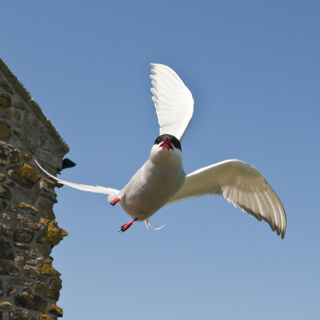

Image:4036 Gt:Artic Tern, 1st Pred:Common Tern, 7.774, 2nd Pred:Artic Tern, 6.959


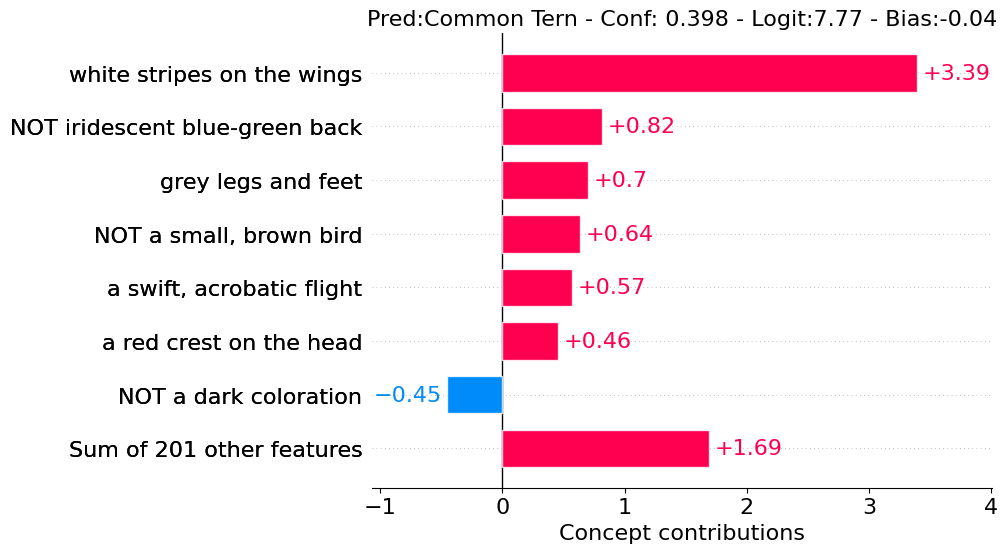

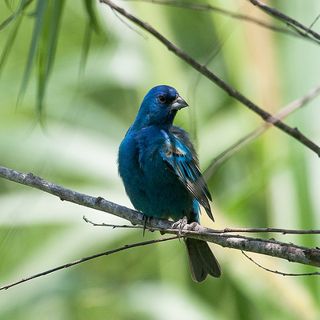

Image:1493 Gt:Blue Grosbeak, 1st Pred:Indigo Bunting, 10.306, 2nd Pred:Cape Glossy Starling, 9.037


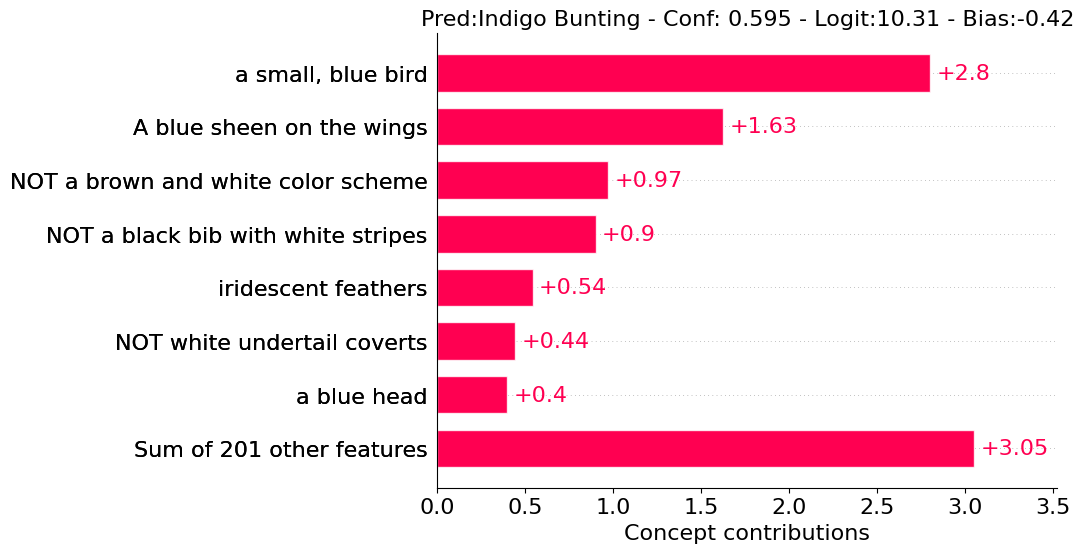

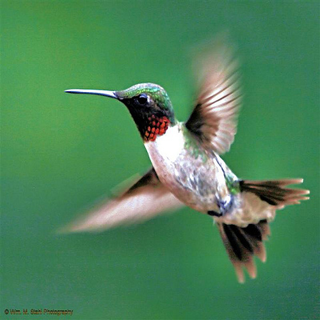

Image:1898 Gt:Ruby throated Hummingbird, 1st Pred:Ruby throated Hummingbird, 5.669, 2nd Pred:Rufous Hummingbird, 4.250


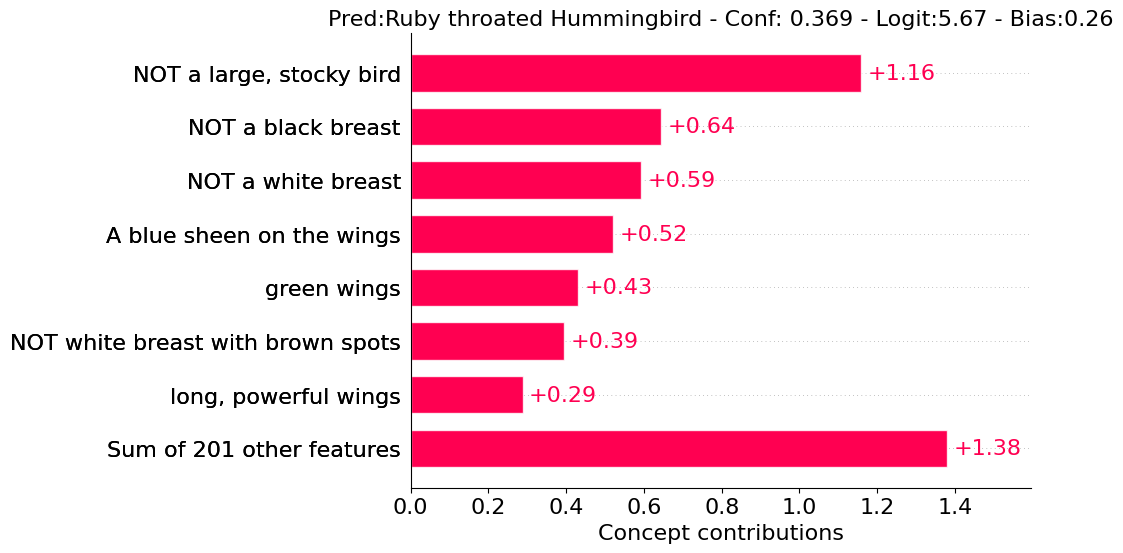

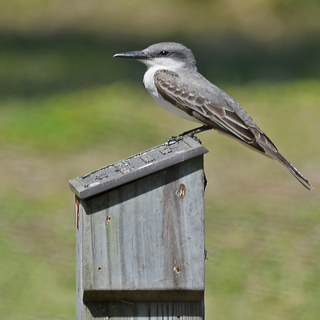

Image:2187 Gt:Gray Kingbird, 1st Pred:Gray Kingbird, 6.094, 2nd Pred:Olive sided Flycatcher, 4.690


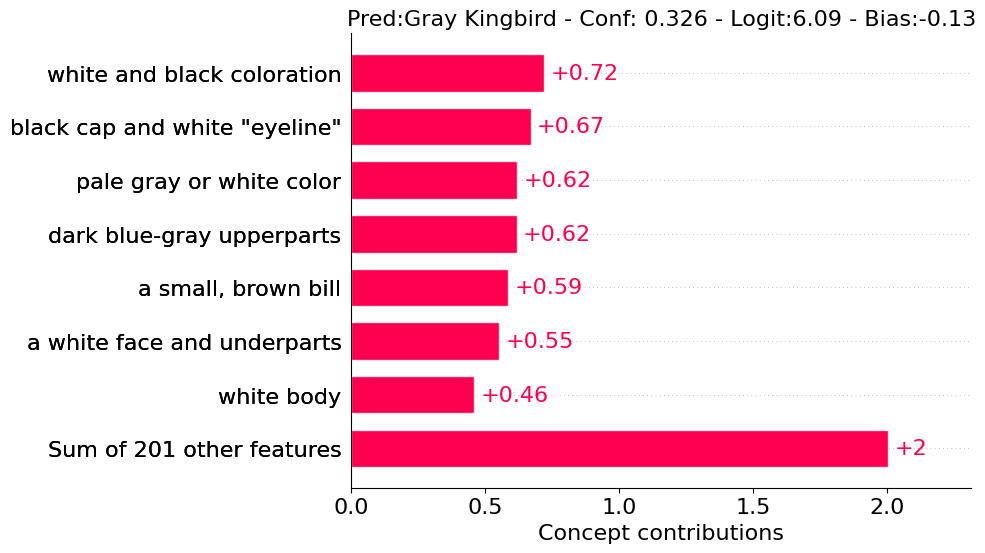

In [9]:
to_display = random.sample([i for i in range(len(val_pil_data))], k=4)

with torch.no_grad():
    for i in to_display:
        image, label = val_pil_data[i]
        x, _ = val_data_t[i]
        x = x.unsqueeze(0).to(device)
        display(image.resize([320,320]))
        
        outputs, concept_act = model(x)
        
        top_logit_vals, top_classes = torch.topk(outputs[0], dim=0, k=2)
        conf = torch.nn.functional.softmax(outputs[0], dim=0)
        print("Image:{} Gt:{}, 1st Pred:{}, {:.3f}, 2nd Pred:{}, {:.3f}".format(i, classes[int(label)], classes[top_classes[0]], top_logit_vals[0],
                                                                      classes[top_classes[1]], top_logit_vals[1]))
        
        for k in range(1):
            contributions = concept_act[0]*model.final.weight[top_classes[k], :]
            feature_names = [("NOT " if concept_act[0][i] < 0 else "") + concepts[i] for i in range(len(concepts))]
            values = contributions.cpu().numpy()
            max_display = min(int(sum(abs(values)>0.005))+1, 8)
            title = "Pred:{} - Conf: {:.3f} - Logit:{:.2f} - Bias:{:.2f}".format(classes[top_classes[k]],
                             conf[top_classes[k]], top_logit_vals[k], model.final.bias[top_classes[k]])
            plots.bar(values, feature_names, max_display=max_display, title=title, fontsize=16)

Ground Truth : Long tailed Jaeger
Predicted    : Pomarine Jaeger ✗

Let's examine each concept from the bar chart versus the bird photo:

1. **blue wings with white bars**
   - **Unclear**: The wings appear mostly dark, but the image lighting and angle make it hard to confirm clear blue coloration or distinct white bars.

2. **fast, erratic flight patterns**
   - **Unclear**: The photo is a still image, so we cannot assess the bird's flight pattern.

3. **blue wings**
   - **Unclear**: The wings look dark, but the exact color (blue) is hard to verify from the photo due to lighting.

4. **a black and white barred tail**
   - **Unclear**: The tail does appear to have some patterning, but it's not clear enough to positively identify black and white barring.

5. **a black wingtip**
   - **Clearly present**: The wingtips are visibly darker than the rest of the wing, matching this description.

6. **yellow bar on wing**
   - **Not present**: There are no visible yellow markings or bars on th

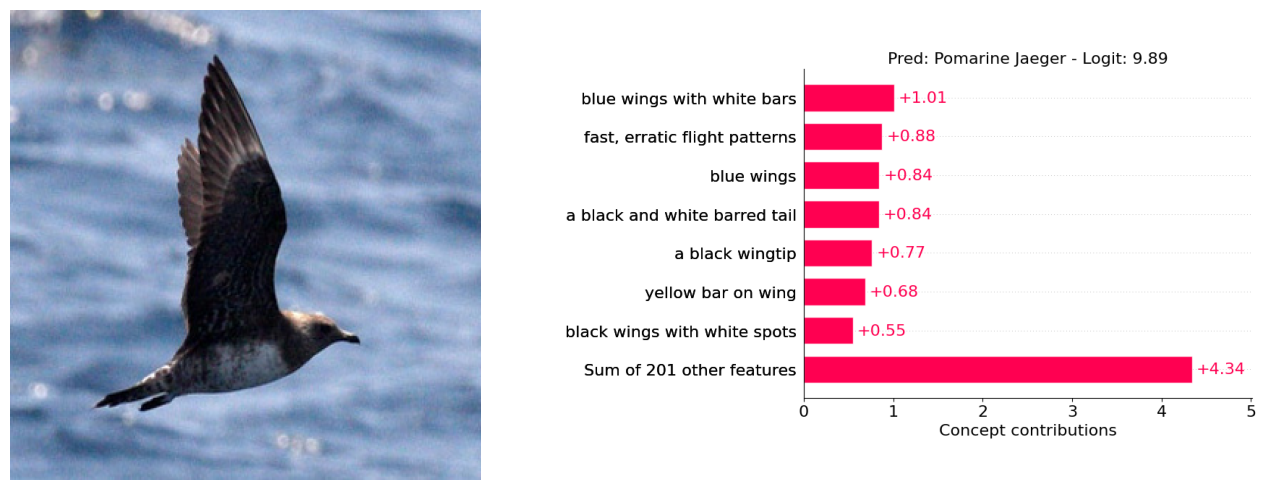

In [52]:
# Sanity Check Concept Activations

import io, base64, os, random
import matplotlib.pyplot as plt
from openai import OpenAI
import torch

os.environ["OPENAI_API_KEY"] = ""
client = OpenAI()

random.seed(51)

def get_img_output():
    i = random.choice(range(len(val_pil_data)))
    image, label = val_pil_data[i]
    x, _ = val_data_t[i]
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs, concept_act = model(x)

    top_logit_vals, top_classes = torch.topk(outputs[0], k=1, dim=0)
    pred_class = top_classes[0]
    pred_label = classes[pred_class]
    gt_label = classes[int(label)]

    contributions = concept_act[0] * model.final.weight[pred_class, :]
    feature_names = [("NOT " if concept_act[0][j] < 0 else "") + concepts[j] for j in range(len(concepts))]
    values = contributions.detach().cpu().numpy()
    max_display = min(int(sum(abs(values) > 0.005)) + 1, 8)
    title = "Pred: {} - Logit: {:.2f}".format(pred_label, top_logit_vals[0])

    plt.show = lambda *args, **kwargs: None
    plots.bar(values, feature_names, max_display=max_display, title=title, fontsize=16)
    fig = plt.gcf()
    buf = io.BytesIO()
    fig.savefig(buf, format="PNG", bbox_inches="tight")
    buf.seek(0)
    fig_b64 = base64.b64encode(buf.read()).decode()
    plt.close(fig)
    plt.show = __builtins__["show"] if isinstance(__builtins__, dict) else plt.show

    return image, fig_b64, pred_label, gt_label

def sanity_check_edges(img, fig_b64):
    img_b64 = base64.b64encode(img.resize([320, 320]).tobytes()).decode()
    buf = io.BytesIO()
    img.resize([320, 320]).save(buf, format="PNG")
    img_b64 = base64.b64encode(buf.getvalue()).decode()

    response = client.chat.completions.create(
        model="gpt-4.1",
        messages=[{"role": "user", "content": [
            {"type": "text", "text": (
                "You are given a bird photo and a bar chart showing concept attributes the model detected. "
                "For each concept in the chart, state if it is clearly present, not present, or unclear in the photo."
                "Give brief reasoning for labelling it as clearly present, not present, or unclear."
            )},
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
            {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{fig_b64}"}},
        ]}],
        max_tokens=400,
    )
    return response.choices[0].message.content

# --- Run ---
img, fig_b64, pred_label, gt_label = get_img_output()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(img.resize([320, 320]))
axes[0].axis("off")
chart_img = plt.imread(io.BytesIO(base64.b64decode(fig_b64)))
axes[1].imshow(chart_img)
axes[1].axis("off")
plt.tight_layout()
plt.show()

correct = "✓" if pred_label == gt_label else "✗"
print(f"Ground Truth : {gt_label}")
print(f"Predicted    : {pred_label} {correct}\n")
print(sanity_check_edges(img, fig_b64))

In [53]:
# Sanity Check Concept-Class Edges

def get_class_weights(class_name):
    class_idx = classes.index(class_name)
    weights = model.final.weight[class_idx].detach().cpu()
    
    # Sort by magnitude
    sorted_indices = torch.argsort(torch.abs(weights), descending=True)
    sorted_concepts = [(concepts[i], float(weights[i])) for i in sorted_indices]
    
    return class_name, sorted_concepts

def sanity_check_class_weights(class_name, sorted_concepts):
    # Format as a readable list for GPT
    concept_list = "\n".join(
        [f"  {'(+)' if w > 0 else '(-)'} {c}: {w:.4f}" for c, w in sorted_concepts]
    )

    prompt = (
        f"You are evaluating a Concept Bottleneck Model trained to classify bird species.\n"
        f"Below are the learned concept weights for the class '{class_name}', "
        f"sorted by magnitude. (+) means the concept supports this class, (-) means it works against it.\n\n"
        f"{concept_list}\n\n"
        f"For each concept, state whether the association makes biological/visual sense for a '{class_name}'. "
        f"Flag any concepts that seem wrong or surprising. "
        f"End with an overall PASS or FAIL verdict."
    )

    response = client.chat.completions.create(
        model="gpt-4.1",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=600,
    )
    return response.choices[0].message.content

# --- Run ---
class_name = classes[10]  # change this to any class you want to inspect

class_name, sorted_concepts = get_class_weights(class_name)
print(f"Top concepts for: {class_name}\n")
for concept, weight in sorted_concepts[:10]:
    sign = "(+)" if weight > 0 else "(-)"
    print(f"  {sign} {concept}: {weight:.4f}")

print("\nGPT Sanity Check:\n")
print(sanity_check_class_weights(class_name, sorted_concepts[:20]))  # send top 20 by magnitude

Top concepts for: Black footed Albatross

  (-) a small, thrush-like bird: -0.6454
  (-) a black bib with white stripes: -0.5833
  (+) long wingspan: 0.4972
  (-) a small songbird: -0.4620
  (-) a glossy sheen to its feathers: -0.4234
  (+) orange and black wings: 0.3867
  (+) grayish wings and tail: 0.3757
  (+) a grayish-brown head: 0.3243
  (-) long tail with white stripes: -0.2977
  (+) a large blue-grey bird: 0.2937

GPT Sanity Check:

Let's review the concepts and weights for **Black footed Albatross (Phoebastria nigripes)**.  
**Biology and visuals relevant:**  
- Large seabird, mostly dark (brownish-black) plumage  
- Long, narrow wings (long wingspan)  
- Black feet (not easily visible in flight)  
- Grayish bill, adults may have some pale on their face  
- Large size, not songbird-like  

Let's go line by line:

---

**Negative Concepts (should not match Black footed Albatross):**  

- **a small, thrush-like bird: -0.6454**  
  *Makes sense*: NOT a small thrush; negative weig

In [1]:
from huggingface_hub import hf_hub_download
print(open(hf_hub_download('imageomics/bioclip', 'open_clip_config.json')).read())

open_clip_config.json:   0%|          | 0.00/469 [00:00<?, ?B/s]

{
  "model_cfg": {
    "embed_dim": 512,
    "vision_cfg": {
      "image_size": 224,
      "layers": 12,
      "width": 768,
      "patch_size": 16
    },
    "text_cfg": {
      "context_length": 77,
      "vocab_size": 49408,
      "width": 512,
      "heads": 8,
      "layers": 12
    }
  },
  "preprocess_cfg": {
    "mean": [
      0.48145466,
      0.4578275,
      0.40821073
    ],
    "std": [
      0.26862954,
      0.26130258,
      0.27577711
    ]
  }
}
